# CNN Optimizer Comparison on MNIST & CIFAR-10
This notebook compares SGD, Momentum, RMSProp, and Adam using **Convolutional Neural Networks** on real datasets: **MNIST** and **CIFAR-10**.

**Data Description**

#### 1. The MNIST database of handwritten digits [link for downloading](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)
* has a training set of 60,000 examples, and a test set of 10,000 examples. Four files are available into the zip provided:

    *1) train-images-idx3-ubyte.gz: training set images (9912422 bytes)*
    
    *2) train-labels-idx1-ubyte.gz: training set labels (28881 bytes)*
    
    *3) t10k-images-idx3-ubyte.gz: test set images (1648877 bytes)*
    
    *4) t10k-labels-idx1-ubyte.gz: test set labels (4542 bytes)*

#### 2. The CIFAR-10 dataset [link for downloading](https://www.kaggle.com/datasets/quanbk/cifar10)

* is made up of 60,000 color images, each 32×32 pixels, grouped into 10 categories with 6,000 images per category. It is split into 50,000 training images and 10,000 test images.

* These images are organized into five training batches and one test batch, each batch containing 10,000 images. The test batch includes exactly 1,000 randomly chosen images from every class. The training batches hold the remaining images, also shuffled, though individual batches may have uneven class distributions. Altogether, the five training batches still provide exactly 5,000 images for each class.

* The classes are strictly distinct. For example, the “automobile” and “truck” categories do not overlap. “Automobile” covers sedans, SUVs, and similar vehicles, while “truck” refers only to large trucks. Pickup trucks are excluded from both categories.

In [2]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(0)

# 1. CNN Architectures

In [3]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(32*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# 2. Load Datasets

In [4]:
transform_mnist = transforms.Compose([transforms.ToTensor()])
transform_cifar = transforms.Compose([transforms.ToTensor()])

mnist_train = torchvision.datasets.MNIST(root='/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Malaria/archive', train=True, download=True, transform=transform_mnist)
cifar_train = torchvision.datasets.CIFAR10(root='/home/student25/Documents/Patrick25/Deep learning and algo/tuto/Malaria/cifar-10', train=True, download=True, transform=transform_cifar)

mnist_loader = torch.utils.data.DataLoader(mnist_train, batch_size=128, shuffle=True)
cifar_loader = torch.utils.data.DataLoader(cifar_train, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 55.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.26MB/s]
100%|██████████| 170M/170M [00:02<00:00, 74.9MB/s]


# 3. Training Function

In [5]:
def run_optimizer(opt_name, model, loader, epochs=1):
    criterion = nn.CrossEntropyLoss()

    if opt_name=='SGD':
        opt = optim.SGD(model.parameters(), lr=0.01)
    elif opt_name=='Momentum':
        opt = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif opt_name=='RMSProp':
        opt = optim.RMSprop(model.parameters(), lr=0.001)
    elif opt_name=='Adam':
        opt = optim.Adam(model.parameters(), lr=0.001)

    losses=[]
    for _ in range(epochs):
        for imgs, labels in loader:
            opt.zero_grad()
            pred = model(imgs)
            loss = criterion(pred, labels)
            loss.backward()
            opt.step()
            losses.append(loss.item())
            if len(losses) >= 200:   # limit for speed
                return losses
    return losses

# 4. Compare on MNIST

Training MNIST with SGD ...
Training MNIST with Momentum ...
Training MNIST with RMSProp ...
Training MNIST with Adam ...


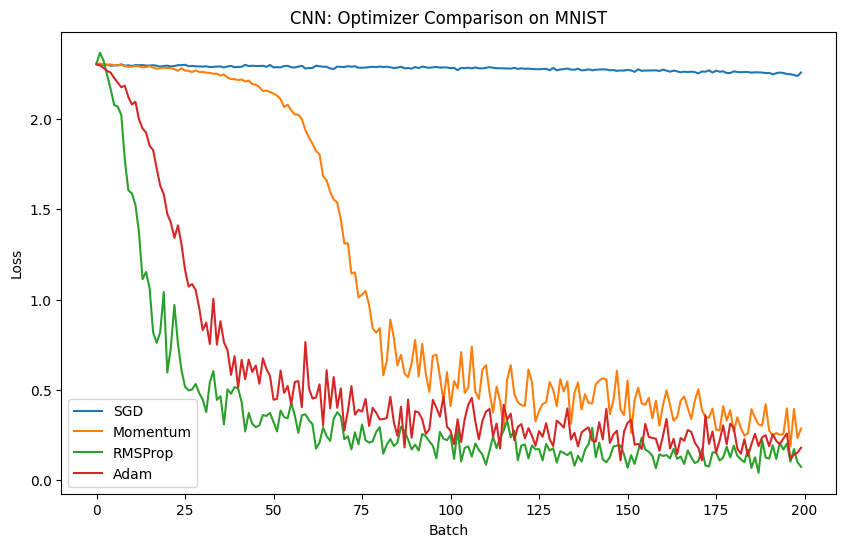

In [ ]:
optims = ["SGD", "Momentum", "RMSProp", "Adam"]
mnist_results = {}

for opt in optims:
    print(f"Training MNIST with {opt} ...")
    model = MNIST_CNN()
    mnist_results[opt] = run_optimizer(opt, model, mnist_loader)

plt.figure(figsize=(10,6))
for k,v in mnist_results.items():
    plt.plot(v, label=k)
plt.legend(); plt.title("CNN: Optimizer Comparison on MNIST"); plt.xlabel("Batch"); plt.ylabel("Loss")
plt.show()

**Interpretation**

* SGD converges the slowest and stays at a high loss.
* Momentum improves on SGD with faster descent but shows some oscillation.
* RMSProp converges fast but with noises.
* Adam is both fast and stable, achieving a loss overall very low and very smooth.

# 5. Compare on CIFAR-10

Training CIFAR-10 with SGD ...
Training CIFAR-10 with Momentum ...
Training CIFAR-10 with RMSProp ...
Training CIFAR-10 with Adam ...


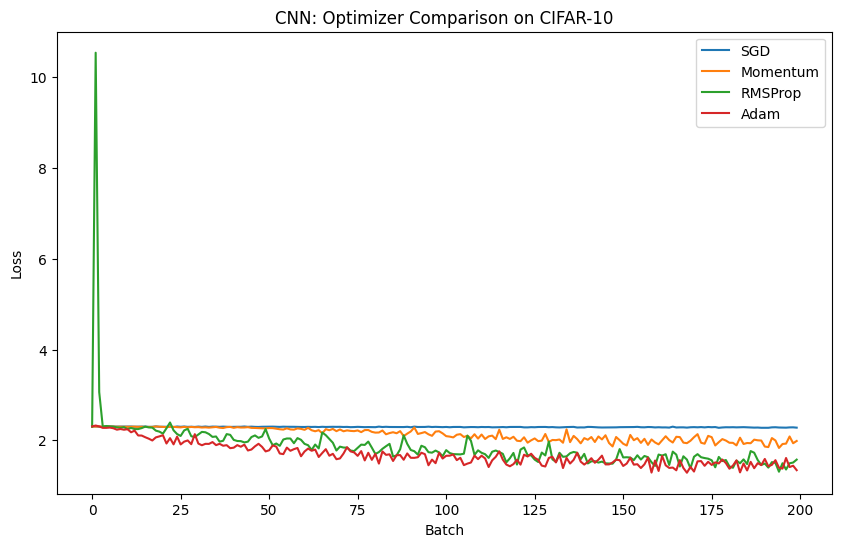

In [ ]:
cifar_results = {}

for opt in optims:
    print(f"Training CIFAR-10 with {opt} ...")
    model = CIFAR_CNN()
    cifar_results[opt] = run_optimizer(opt, model, cifar_loader)

plt.figure(figsize=(10,6))
for k,v in cifar_results.items():
    plt.plot(v, label=k)
plt.legend(); plt.title("CNN: Optimizer Comparison on CIFAR-10"); plt.xlabel("Batch"); plt.ylabel("Loss")
plt.show()

**Interpretation**

* SGD again converges the slowest and stays at the highest loss among other optimizers.
* Momentum improves over plain SGD with slightly faster and lower loss.
* RMSProp drops quickly but shows noises throughout the training process.
* Adam achieves the lowest and smoothest loss, and converging faster than the others.